# 04 — Results Visualization

This notebook loads the saved modeling results, compares Random Forest and Lasso performance across crystal systems, visualizes permutation importance with uncertainty, and saves final figures for the report.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Locate the repository root
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_dir = project_root / "data"
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Load saved modeling results
rf_results = pd.read_csv(
    data_dir / "crystal_system_rf_results.csv"
)

lasso_results = pd.read_csv(
    data_dir / "crystal_system_lasso_results.csv"
)

permutation_results = pd.read_csv(
    data_dir / "crystal_system_permutation_importance_summary.csv"
)

print("Random Forest results:", rf_results.shape)
print("Lasso results:", lasso_results.shape)
print("Permutation-importance results:", permutation_results.shape)
print("Figures directory:", figures_dir.resolve())

display(rf_results.head())
display(lasso_results.head())
display(permutation_results.head())

Random Forest results: (7, 7)
Lasso results: (7, 10)
Permutation-importance results: (966, 8)
Figures directory: C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures


,crystal_system,n_samples,n_reduced_formula_groups,mae_mean,mae_std,r2_mean,r2_std
0,Triclinic,9095,4749,0.503039,0.023535,0.677227,0.026463
1,Monoclinic,14447,10061,0.566626,0.011099,0.728809,0.009972
2,Cubic,1782,1634,0.572287,0.042812,0.662651,0.033003
3,Trigonal,2796,2374,0.583419,0.014497,0.691889,0.019343
4,Tetragonal,2727,2333,0.586820,0.030015,0.684289,0.034095


,crystal_system,n_samples,n_reduced_formula_groups,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,median_selected_alpha
0,Triclinic,9095,4749,0.663266,0.027756,0.883603,0.037036,0.500630,0.031569,0.001000
1,Trigonal,2796,2374,0.739794,0.010967,0.954412,0.022201,0.561249,0.028819,0.001000
2,Cubic,1782,1634,0.769563,0.032223,0.981072,0.039715,0.486672,0.066696,0.001995
3,Orthorhombic,8160,6104,0.775816,0.006915,0.998391,0.009031,0.538799,0.042854,0.001000
4,Monoclinic,14447,10061,0.800200,0.014182,1.015785,0.011368,0.538484,0.009421,0.001000


,crystal_system,feature,mean_mae_increase,std_across_seeds,mean_within_seed_std,top3_seed_count,positive_seed_count,mean_rank
0,Cubic,formation_energy_per_atom,0.282624,0.024240,0.023056,5,5,1.0
1,Cubic,energy_above_hull,0.216079,0.020266,0.019614,5,5,2.0
2,Cubic,MagpieData avg_dev NdValence,0.119124,0.019507,0.014039,4,5,3.2
3,Cubic,MagpieData mean NdValence,0.070190,0.025036,0.011717,1,5,3.8
4,Cubic,nsites,0.030338,0.009438,0.006877,0,5,5.4


## Global Random Forest Parity Plot

The parity plot compares leakage-free out-of-fold Random Forest predictions
with the DFT-calculated band gaps. Predictions were generated using five-fold
GroupKFold cross-validation grouped by reduced formula, so each point was
predicted by a model that did not train on that composition group.

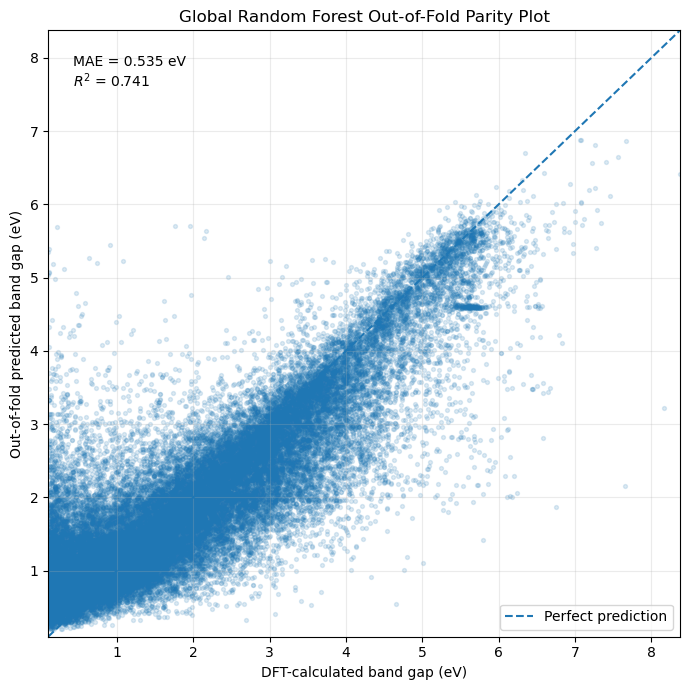

Saved figure to: figures\global_rf_oof_parity_plot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Load leakage-free out-of-fold predictions
oof_predictions_df = pd.read_csv(
    data_dir / "global_rf_oof_predictions.csv"
)

actual = oof_predictions_df["actual_band_gap"]
predicted = oof_predictions_df["predicted_band_gap"]

parity_mae = mean_absolute_error(actual, predicted)
parity_r2 = r2_score(actual, predicted)

axis_min = min(actual.min(), predicted.min())
axis_max = max(actual.max(), predicted.max())

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    actual,
    predicted,
    s=8,
    alpha=0.15,
    rasterized=True
)

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction"
)

ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)

ax.set_xlabel("DFT-calculated band gap (eV)")
ax.set_ylabel("Out-of-fold predicted band gap (eV)")
ax.set_title("Global Random Forest Out-of-Fold Parity Plot")

ax.text(
    0.04,
    0.96,
    f"MAE = {parity_mae:.3f} eV\n$R^2$ = {parity_r2:.3f}",
    transform=ax.transAxes,
    va="top"
)

ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

parity_figure_path = figures_dir / "global_rf_oof_parity_plot.png"

fig.savefig(
    parity_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", parity_figure_path.relative_to(project_root))

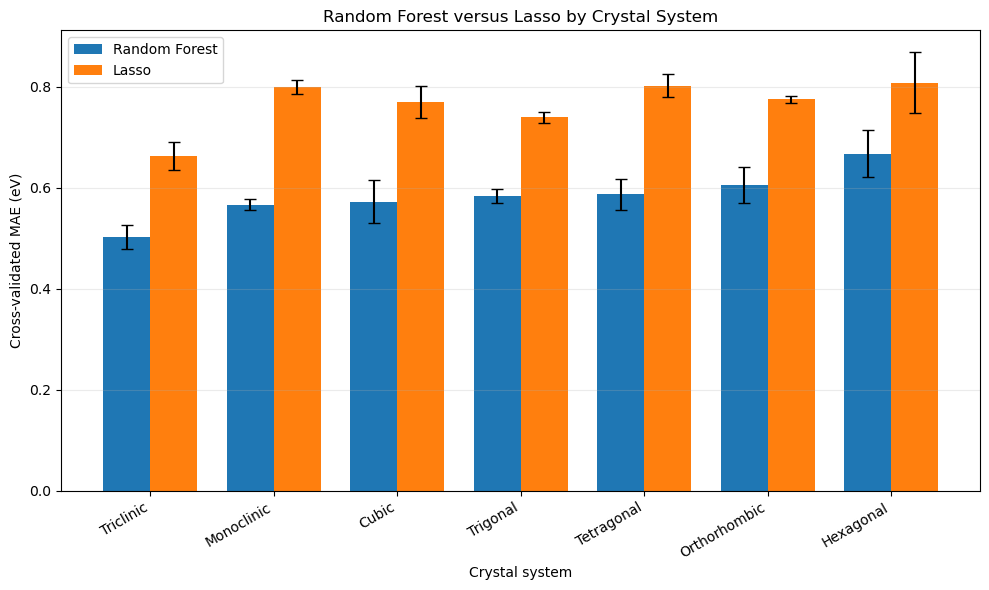

Saved figure to:
C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\rf_vs_lasso_mae_by_crystal_system.png


,crystal_system,mae_mean_rf,mae_std_rf,mae_mean_lasso,mae_std_lasso
0,Triclinic,0.503,0.024,0.663,0.028
1,Monoclinic,0.567,0.011,0.800,0.014
2,Cubic,0.572,0.043,0.770,0.032
3,Trigonal,0.583,0.014,0.740,0.011
4,Tetragonal,0.587,0.030,0.802,0.023
5,Orthorhombic,0.606,0.036,0.776,0.007
6,Hexagonal,0.667,0.047,0.808,0.060


In [3]:
# Compare Random Forest and Lasso MAE across crystal systems

performance_comparison = pd.merge(
    rf_results,
    lasso_results,
    on=[
        "crystal_system",
        "n_samples",
        "n_reduced_formula_groups"
    ],
    suffixes=("_rf", "_lasso")
)

# Order crystal systems by Random Forest MAE
performance_comparison = (
    performance_comparison
    .sort_values("mae_mean_rf")
    .reset_index(drop=True)
)

x = np.arange(len(performance_comparison))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - bar_width / 2,
    performance_comparison["mae_mean_rf"],
    width=bar_width,
    yerr=performance_comparison["mae_std_rf"],
    capsize=4,
    label="Random Forest"
)

ax.bar(
    x + bar_width / 2,
    performance_comparison["mae_mean_lasso"],
    width=bar_width,
    yerr=performance_comparison["mae_std_lasso"],
    capsize=4,
    label="Lasso"
)

ax.set_xticks(x)
ax.set_xticklabels(
    performance_comparison["crystal_system"],
    rotation=30,
    ha="right"
)

ax.set_xlabel("Crystal system")
ax.set_ylabel("Cross-validated MAE (eV)")
ax.set_title(
    "Random Forest versus Lasso by Crystal System"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

mae_figure_path = (
    figures_dir
    / "rf_vs_lasso_mae_by_crystal_system.png"
)

fig.savefig(
    mae_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:")
print(mae_figure_path.resolve())

display(
    performance_comparison[
        [
            "crystal_system",
            "mae_mean_rf",
            "mae_std_rf",
            "mae_mean_lasso",
            "mae_std_lasso"
        ]
    ].round(3)
)

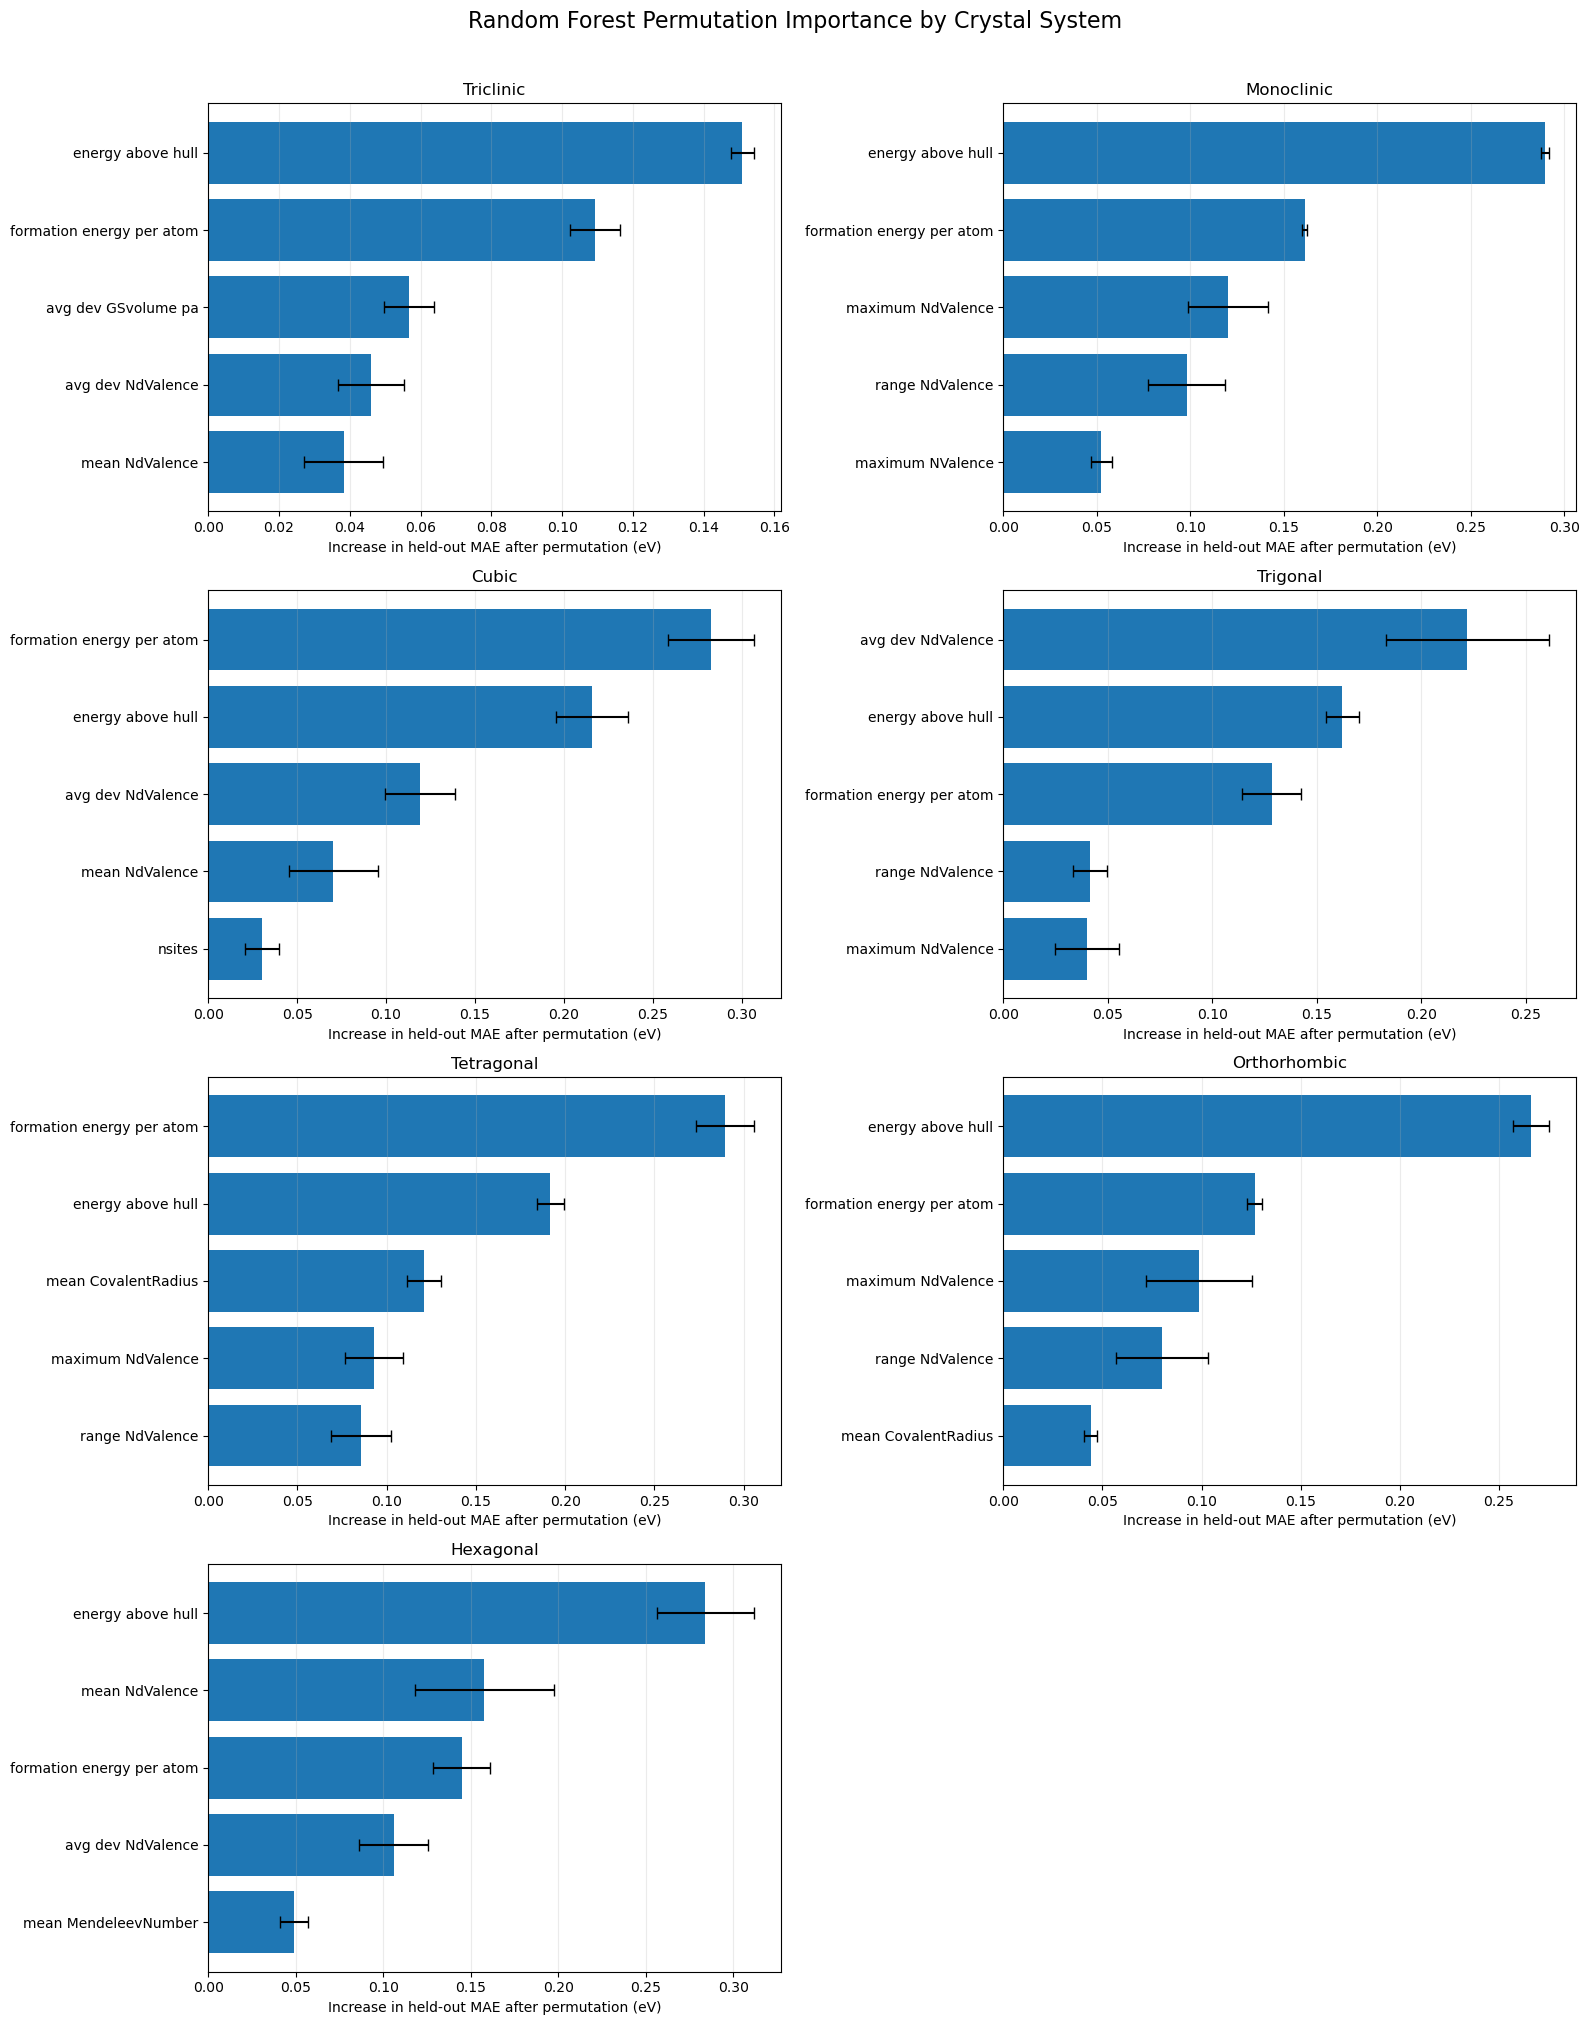

Saved figure to:
C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\permutation_importance_by_crystal_system.png


In [4]:
# Permutation importance with seed-to-seed uncertainty
# Display the five most important features for each crystal system

crystal_order = performance_comparison[
    "crystal_system"
].tolist()

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 20)
)

axes = axes.flatten()


def clean_feature_name(feature):
    return (
        feature
        .replace("MagpieData ", "")
        .replace("_", " ")
    )


for ax, crystal_system in zip(
    axes,
    crystal_order
):

    top_features = (
        permutation_results[
            permutation_results["crystal_system"]
            == crystal_system
        ]
        .nlargest(
            5,
            "mean_mae_increase"
        )
        .sort_values(
            "mean_mae_increase",
            ascending=True
        )
        .copy()
    )

    top_features["display_feature"] = (
        top_features["feature"]
        .apply(clean_feature_name)
    )

    ax.barh(
        top_features["display_feature"],
        top_features["mean_mae_increase"],
        xerr=top_features["std_across_seeds"],
        capsize=4
    )

    ax.set_title(crystal_system)
    ax.set_xlabel(
        "Increase in held-out MAE after permutation (eV)"
    )
    ax.grid(
        axis="x",
        alpha=0.25
    )


# Hide the unused eighth panel
for unused_ax in axes[len(crystal_order):]:
    unused_ax.axis("off")


fig.suptitle(
    "Random Forest Permutation Importance by Crystal System",
    fontsize=16,
    y=1.01
)

fig.tight_layout()

importance_figure_path = (
    figures_dir
    / "permutation_importance_by_crystal_system.png"
)

fig.savefig(
    importance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:")
print(importance_figure_path.resolve())

In [5]:
# Compare the top three Random Forest and Lasso features
# within each crystal system

lasso_feature_results = pd.read_csv(
    data_dir / "crystal_system_lasso_feature_summary.csv"
)

comparison_rows = []

for crystal_system in crystal_order:

    rf_top3 = (
        permutation_results[
            permutation_results["crystal_system"]
            == crystal_system
        ]
        .nlargest(
            3,
            "mean_mae_increase"
        )["feature"]
        .tolist()
    )

    lasso_top3 = (
        lasso_feature_results[
            lasso_feature_results["crystal_system"]
            == crystal_system
        ]
        .nlargest(
            3,
            "mean_absolute_coefficient"
        )["feature"]
        .tolist()
    )

    overlapping_features = sorted(
        set(rf_top3).intersection(lasso_top3)
    )

    comparison_rows.append({
        "crystal_system": crystal_system,
        "rf_top_1": rf_top3[0],
        "rf_top_2": rf_top3[1],
        "rf_top_3": rf_top3[2],
        "lasso_top_1": lasso_top3[0],
        "lasso_top_2": lasso_top3[1],
        "lasso_top_3": lasso_top3[2],
        "overlap_count": len(overlapping_features),
        "overlapping_features": (
            "; ".join(overlapping_features)
            if overlapping_features
            else "None"
        )
    })

top_feature_comparison = pd.DataFrame(
    comparison_rows
)

comparison_path = (
    data_dir
    / "rf_lasso_top_feature_comparison.csv"
)

top_feature_comparison.to_csv(
    comparison_path,
    index=False
)

display(top_feature_comparison)

print("\nSaved comparison to:")
print(comparison_path.resolve())

,crystal_system,rf_top_1,rf_top_2,rf_top_3,lasso_top_1,lasso_top_2,lasso_top_3,overlap_count,overlapping_features
0,Triclinic,energy_above_hull,formation_energy_per_atom,MagpieData avg_dev GSvolume_pa,formation_energy_per_atom,MagpieData maximum Row,MagpieData avg_dev NdValence,1,formation_energy_per_atom
1,Monoclinic,energy_above_hull,formation_energy_per_atom,MagpieData maximum NdValence,MagpieData maximum AtomicWeight,MagpieData range Number,formation_energy_per_atom,1,formation_energy_per_atom
2,Cubic,formation_energy_per_atom,energy_above_hull,MagpieData avg_dev NdValence,formation_energy_per_atom,MagpieData avg_dev Number,MagpieData mean NdValence,1,formation_energy_per_atom
3,Trigonal,MagpieData avg_dev NdValence,energy_above_hull,formation_energy_per_atom,MagpieData maximum AtomicWeight,formation_energy_per_atom,MagpieData maximum Number,1,formation_energy_per_atom
4,Tetragonal,formation_energy_per_atom,energy_above_hull,MagpieData mean CovalentRadius,MagpieData avg_dev Number,MagpieData mean NfValence,MagpieData avg_dev NfValence,0,None
5,Orthorhombic,energy_above_hull,formation_energy_per_atom,MagpieData maximum NdValence,formation_energy_per_atom,MagpieData avg_dev Number,MagpieData mean GSbandgap,1,formation_energy_per_atom
6,Hexagonal,energy_above_hull,MagpieData mean NdValence,formation_energy_per_atom,formation_energy_per_atom,MagpieData avg_dev Electronegativity,density,1,formation_energy_per_atom



Saved comparison to:
C:\Users\24250\Desktop\zhao-oxide-bandgap-project\data\rf_lasso_top_feature_comparison.csv


### Random Forest and Lasso Feature Comparison

Random Forest and Lasso showed partial, but not complete, agreement about the most influential predictors. Formation energy per atom appeared in the top three features of both models for six of the seven crystal systems. This repeated agreement suggests that thermodynamic stability is a robust predictor of band gap in oxygen-containing materials across different model classes.

The remaining highly ranked features differed substantially between the models. Random Forest frequently emphasized energy above the convex hull and NdValence-related descriptors, whereas Lasso selected a broader mixture of elemental-property statistics. The tetragonal subset showed no overlap between the two models' top-three feature lists.

These differences are expected because permutation importance measures the predictive contribution of a feature within a nonlinear Random Forest, including interactions with other variables, while the magnitude of a standardized Lasso coefficient reflects only a sparse linear relationship. Therefore, disagreement does not necessarily indicate an unreliable result; instead, it suggests that some band-gap relationships are nonlinear or depend on feature interactions.

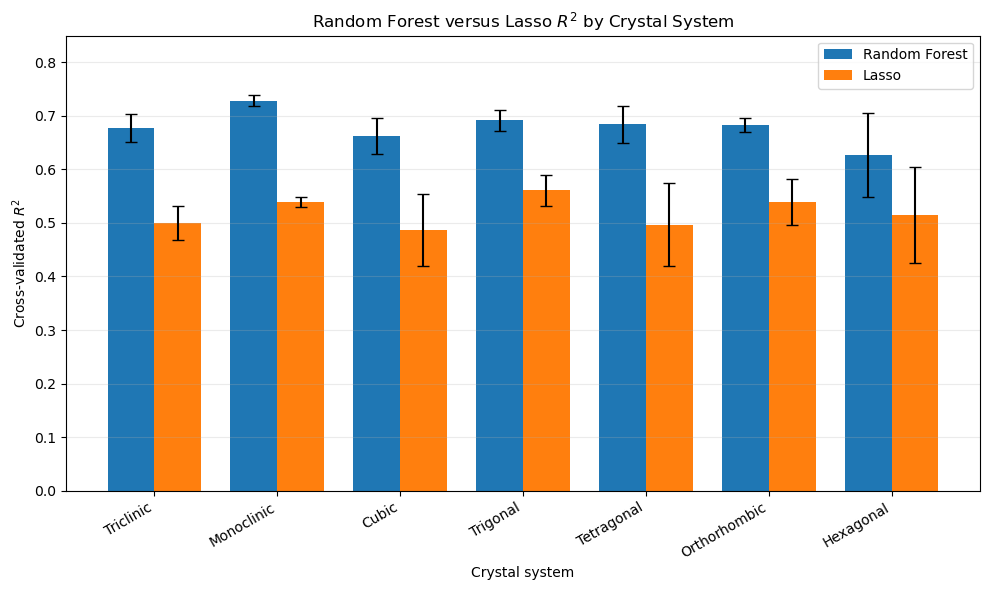

Saved figure to:
C:\Users\24250\Desktop\zhao-oxide-bandgap-project\figures\rf_vs_lasso_r2_by_crystal_system.png


,crystal_system,r2_mean_rf,r2_std_rf,r2_mean_lasso,r2_std_lasso
0,Triclinic,0.677,0.026,0.501,0.032
1,Monoclinic,0.729,0.010,0.538,0.009
2,Cubic,0.663,0.033,0.487,0.067
3,Trigonal,0.692,0.019,0.561,0.029
4,Tetragonal,0.684,0.034,0.497,0.077
5,Orthorhombic,0.683,0.012,0.539,0.043
6,Hexagonal,0.627,0.079,0.514,0.089


In [6]:
# Compare Random Forest and Lasso R² across crystal systems

x = np.arange(len(performance_comparison))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - bar_width / 2,
    performance_comparison["r2_mean_rf"],
    width=bar_width,
    yerr=performance_comparison["r2_std_rf"],
    capsize=4,
    label="Random Forest"
)

ax.bar(
    x + bar_width / 2,
    performance_comparison["r2_mean_lasso"],
    width=bar_width,
    yerr=performance_comparison["r2_std_lasso"],
    capsize=4,
    label="Lasso"
)

ax.set_xticks(x)
ax.set_xticklabels(
    performance_comparison["crystal_system"],
    rotation=30,
    ha="right"
)

ax.set_xlabel("Crystal system")
ax.set_ylabel("Cross-validated $R^2$")
ax.set_title(
    "Random Forest versus Lasso $R^2$ by Crystal System"
)

ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

r2_figure_path = (
    figures_dir
    / "rf_vs_lasso_r2_by_crystal_system.png"
)

fig.savefig(
    r2_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:")
print(r2_figure_path.resolve())

display(
    performance_comparison[
        [
            "crystal_system",
            "r2_mean_rf",
            "r2_std_rf",
            "r2_mean_lasso",
            "r2_std_lasso"
        ]
    ].round(3)
)

### Model-Performance Summary

Random Forest consistently outperformed Lasso for every crystal system in both MAE and \(R^2\). The Random Forest \(R^2\) values ranged from approximately 0.627 to 0.729, whereas the Lasso values ranged from approximately 0.487 to 0.561.

The monoclinic Random Forest achieved the highest \(R^2\), approximately 0.729, while the hexagonal model had the lowest value, approximately 0.627. The relatively large uncertainty for the hexagonal subset is consistent with its smaller sample size and lower number of reduced-formula groups.

Together with the MAE comparison, these results show that nonlinear Random Forest models capture substantially more of the variation in the band gaps of oxygen-containing materials than sparse linear Lasso models. Separate crystal-system models also exhibit different predictive performance and feature-importance patterns, supporting the use of crystal-system-specific analysis.

In [7]:
# Create a compact final performance summary table

final_performance_table = (
    performance_comparison[
        [
            "crystal_system",
            "n_samples",
            "n_reduced_formula_groups",
            "mae_mean_rf",
            "mae_std_rf",
            "r2_mean_rf",
            "r2_std_rf",
            "mae_mean_lasso",
            "mae_std_lasso",
            "r2_mean_lasso",
            "r2_std_lasso"
        ]
    ]
    .copy()
)

final_performance_table[
    "mae_improvement_rf_over_lasso"
] = (
    final_performance_table["mae_mean_lasso"]
    - final_performance_table["mae_mean_rf"]
)

final_performance_table[
    "r2_improvement_rf_over_lasso"
] = (
    final_performance_table["r2_mean_rf"]
    - final_performance_table["r2_mean_lasso"]
)

final_performance_table = (
    final_performance_table
    .sort_values("mae_mean_rf")
    .reset_index(drop=True)
)

final_summary_path = (
    data_dir
    / "final_model_performance_summary.csv"
)

final_performance_table.to_csv(
    final_summary_path,
    index=False
)

display(
    final_performance_table.round(3)
)

print("\nSaved final performance summary to:")
print(final_summary_path.resolve())

,crystal_system,n_samples,n_reduced_formula_groups,mae_mean_rf,mae_std_rf,r2_mean_rf,r2_std_rf,mae_mean_lasso,mae_std_lasso,r2_mean_lasso,r2_std_lasso,mae_improvement_rf_over_lasso,r2_improvement_rf_over_lasso
0,Triclinic,9095,4749,0.503,0.024,0.677,0.026,0.663,0.028,0.501,0.032,0.160,0.177
1,Monoclinic,14447,10061,0.567,0.011,0.729,0.010,0.800,0.014,0.538,0.009,0.234,0.190
2,Cubic,1782,1634,0.572,0.043,0.663,0.033,0.770,0.032,0.487,0.067,0.197,0.176
3,Trigonal,2796,2374,0.583,0.014,0.692,0.019,0.740,0.011,0.561,0.029,0.156,0.131
4,Tetragonal,2727,2333,0.587,0.030,0.684,0.034,0.802,0.023,0.497,0.077,0.215,0.187
5,Orthorhombic,8160,6104,0.606,0.036,0.683,0.012,0.776,0.007,0.539,0.043,0.170,0.144
6,Hexagonal,1071,913,0.667,0.047,0.627,0.079,0.808,0.060,0.514,0.089,0.141,0.113



Saved final performance summary to:
C:\Users\24250\Desktop\zhao-oxide-bandgap-project\data\final_model_performance_summary.csv


## Final Conclusions

Using five-fold GroupKFold validation grouped by reduced formula, Random Forest consistently outperformed Lasso across all seven crystal systems. Random Forest reduced MAE by approximately 0.141–0.234 eV and increased \(R^2\) by approximately 0.113–0.190 relative to Lasso.

The triclinic Random Forest achieved the lowest MAE at approximately 0.503 eV, while the monoclinic Random Forest achieved the highest \(R^2\) at approximately 0.729. The hexagonal subset showed the weakest and most uncertain Random Forest performance, likely reflecting its smaller sample size and fewer unique reduced-formula groups.

Permutation importance showed that thermodynamic-stability descriptors, especially energy above the convex hull and formation energy per atom, were consistently influential. NdValence-related MAGPIE descriptors also appeared frequently, but their rankings differed across crystal systems. These results indicate that band-gap prediction for oxygen-containing materials depends on nonlinear relationships whose relative importance varies among structural groups.

Overall, the results support crystal-system-specific interpretation, while Random Forest provides substantially better predictive performance than sparse linear Lasso models.